# Proyek Klasifikasi Gambar: Urban Drainage and Flood Monitoring Dataset
- **Nama:** Diva Syabina Putri
- **ID Kelas:** CAC-06
- **Cohort ID:** cacc307d6x0932

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive, files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Install library pembagi folder & TFJS
!pip install split-folders tensorflowjs
import splitfolders

# Mount Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Data Loading

In [2]:
path_zip = '/content/drive/MyDrive/dataset_tata_kota/Bahan_Zip/archive (4).zip'
local_zip = '/content/dataset_asli.zip'

if os.path.exists(path_zip):
    shutil.copyfile(path_zip, local_zip)
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset_unzipped')

    # Mencari folder utama yang berisi subfolder (Banjir, Normal, Tersumbat)
    root_path = '/content/dataset_unzipped'
    subfolders = [f.path for f in os.scandir(root_path) if f.is_dir() and not f.name.startswith('.')]

    # Jika terbungkus satu folder lagi (seperti cityscapes_data), masuk lebih dalam
    if len(subfolders) == 1:
        input_folder = subfolders[0]
    else:
        input_folder = root_path

    # Split fisik: Train 80%, Val 10%, Test 10% (WAJIB DICODING)
    if os.path.exists('dataset_final'): shutil.rmtree('dataset_final')
    splitfolders.ratio(input_folder, output="dataset_final", seed=1337, ratio=(.8, .1, .1))
    print(f"Dataset siap di: {input_folder}")
else:
    print("ERROR: File ZIP tidak ditemukan!")

Copying files: 3475 files [00:01, 1843.74 files/s]

Dataset siap di: /content/dataset_unzipped/cityscapes_data


### Data Preprocessing

#### Split Dataset

In [3]:
train_dir = 'dataset_final/train'
val_dir = 'dataset_final/val'
test_dir = 'dataset_final/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # Lebih luas agar model lebih adaptif
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,         # Zoom agar detail sumbatan/sampah tertangkap
    horizontal_flip=True,
    fill_mode='nearest'
)

# Val & Test TIDAK BOLEH di-augmentasi (Data Murni)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)
val_generator = test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)

Found 2780 images belonging to 3 classes.
Found 347 images belonging to 3 classes.
Found 348 images belonging to 3 classes.


## Modelling

In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.BatchNormalization(), # Biar belajar lebih stabil
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Gunakan learning rate yang sedikit lebih dinamis
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 41s 322ms/step - accuracy: 0.7730 - loss: 1.3623 - val_accuracy: 0.0000e+00 - val_loss: 16.4169
Epoch 2/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 236ms/step - accuracy: 0.8489 - loss: 0.4681 - val_accuracy: 0.0490 - val_loss: 7.3188
Epoch 3/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - accuracy: 0.8547 - loss: 0.4410 - val_accuracy: 0.8559 - val_loss: 0.9544
Epoch 4/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.8554 - loss: 0.4275 - val_accuracy: 0.8559 - val_loss: 0.6018
Epoch 5/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.8590 - loss: 0.4267 - val_accuracy: 0.8559 - val_loss: 0.4207
Epoch 6/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 236ms/step - accuracy: 0.8583 - loss: 0.4199 - val_accuracy: 0.8588 - val_loss: 0.4151
Epoch 7/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.8558 - loss: 0.4164 - val_accuracy: 0.8588 - val_loss: 0.3993
Epoch 8/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 41s 250ms/step - accuracy: 0.8586 - loss: 0.4192 - val

## Evaluasi dan Visualisasi

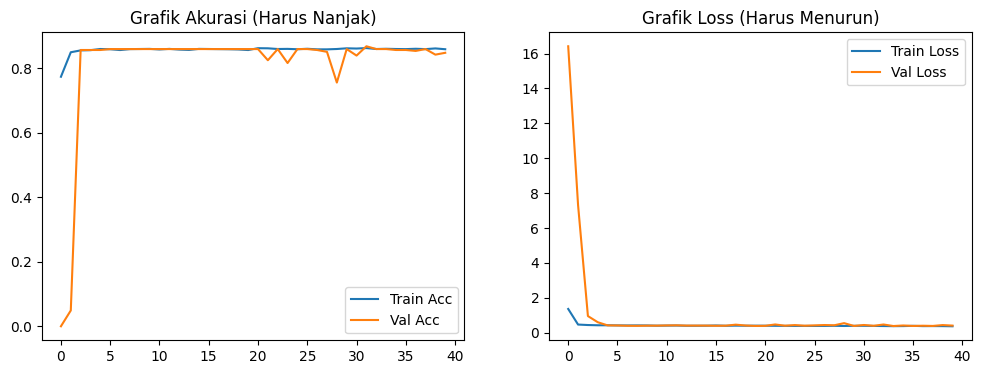


 UJI COBA PADA DATA TESTING (UNSEEN DATA):
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.8678 - loss: 0.3959
Akurasi Akhir Testing: 86.78%


In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Grafik Akurasi (Harus Nanjak)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss (Harus Menurun)')
plt.legend()
plt.show()

print("\n UJI COBA PADA DATA TESTING (UNSEEN DATA):")
test_loss, test_acc = model.evaluate(test_generator)
print(f'Akurasi Akhir Testing: {test_acc*100:.2f}%')

## Konversi Model

In [6]:
model.export('saved_model')
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, 'tfjs_model')
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
with open('model.tflite', 'wb') as f: f.write(converter.convert())

!zip -r submission_final_diva.zip saved_model tfjs_model model.tflite
files.download('submission_final_diva.zip')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138780376747664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376755920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376753808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376753616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376755152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376755728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376756688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376757840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376758032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138780376756304: Te

failed to lookup keras version from the file,
    this is likely a weight only file
  adding: saved_model/ (stored 0%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 87%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 69%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard14of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard10of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard19of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard17of19.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 88%)
  adding: tfjs_model/group1-shard5of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard12of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard8of19.bin (deflated 7%)
  adding: tfjs_model/group1-shard6of19.bin (deflated 7%)
  adding: tf

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

In [7]:
uploaded = files.upload()

for fn in uploaded.keys():
  img = image.load_img(fn, target_size=(150, 150))
  img_tensor = image.img_to_array(img) / 255.0
  img_tensor = np.expand_dims(img_tensor, axis=0)

  prediction = model.predict(img_tensor)
  idx = np.argmax(prediction)

  classes = ['Banjir', 'Normal', 'Tersumbat']
  print(f'File: {fn} | Hasil: {classes[idx]} ({prediction[0][idx]*100:.2f}%)')

Saving sampah to sampah (1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
File: sampah (1) | Hasil: Tersumbat (51.98%)
